### **8. Implementation Workflow**

1. **Initialize**:
    - Set up neuron potentials, synaptic weights, and parameters (α,u,τJ,Iext).
        
        α,u,τJ,Iext\alpha, u, \tau_J, I_{\text{ext}}
        
2. **Time Loop**:
    - For each time step:
        1. Update neuron potentials based on input and synaptic dynamics.
        2. Detect and propagate spikes.
        3. Update synaptic strengths using their dynamics.
3. **Data Collection**:
    - Record avalanche sizes and system state.
4. **Analysis and Plotting**:
    - Analyze distributions, fit power laws, and visualize results.

In [12]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from multiprocessing import Pool, Manager
from scipy.stats import linregress

In [641]:
N = 300
alpha = 1.4
uu = 0.2
tau_J = 10
tau_ext = 30
tau_d = 1 # delay input
theta = 1
I_ext = 0.25
max_time = 100000
dt = 0.01  
treshold = 1
hi = np.float16(np.random.uniform(0, treshold, N))
array_neurons = np.arange(0,N)
initial_potentials = dict(zip(array_neurons, hi))

In [642]:
#G = nx.erdos_renyi_graph(N, 1) # Red con 0.05 vecinos por neurona aprox
G = nx.complete_graph(N)
isolated_nodes = list(np.argwhere(np.array(G.degree())[:,1]==0).flatten()) # Encontrar nodos no conectados para eliminarlos
#G.remove_nodes_from(isolated_nodes)
for u, v, data in G.edges(data=True):
    data['weight'] = np.random.uniform(0.5, alpha / uu) # Inicializamos por pesos random hasta el peso límite
    
nx.set_node_attributes(G, initial_potentials, 'potential') # Inicializamos el atributo potential con potenciales random abajo de umbral

In [643]:
tau_spikes_track = []
avalanches_size = []
time_series = []
current_avalanche = 0
for t in range(max_time):
    if t % tau_ext == 0: # Aplicar corriente externa cada tau_input
        random_node = np.random.randint(N)
        G.nodes[random_node]['potential'] += I_ext
        if current_avalanche > 0:
            avalanches_size.append(current_avalanche)
            current_avalanche = 0
    
    current_potentials = nx.get_node_attributes(G, "potential")
    current_potentials = np.array(list(current_potentials.values()))
    spike_neurons = np.argwhere(current_potentials > theta).flatten()
    current_potentials[spike_neurons] -= 1
    
    nx.set_node_attributes(G, dict(zip(array_neurons, current_potentials)), 'potential')
    tau_spikes_track.append(spike_neurons)

    for u, v, data in G.edges(data=True):
        #print('antes', data['weight'])
        data['weight'] += (alpha / uu - data['weight']) * (dt / tau_J)
        #print('despues', data['weight'])
    if t > tau_d:
        tau_spikes_track.pop(0)
        len_spikes = len(tau_spikes_track[0])
        if len_spikes != 0:
            current_avalanche += len_spikes
            time_series.append(current_avalanche)
            #print(tau_spikes_track[1].shape[0])
            for pre_synaptic in tau_spikes_track[0]:
                post_synaptics = list(G.neighbors(int(pre_synaptic)))
                for post_synaptic in post_synaptics:
                    weight = G[int(pre_synaptic)][int(post_synaptic)]['weight']
                    #print('antes', G.nodes[int(post_synaptic)]['potential'])
                    G.nodes[int(post_synaptic)]['potential'] += (1 / N) * uu * weight
                    
                    G[int(pre_synaptic)][int(post_synaptic)]['weight'] = weight - uu
                    #print('despues', G.nodes[int(post_synaptic)]['potential'])
    

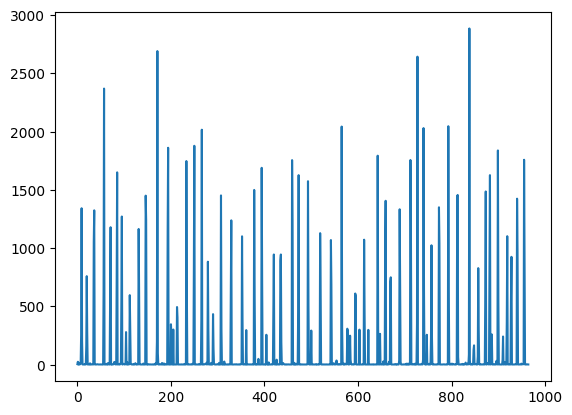

In [644]:
plt.plot(avalanches_size)

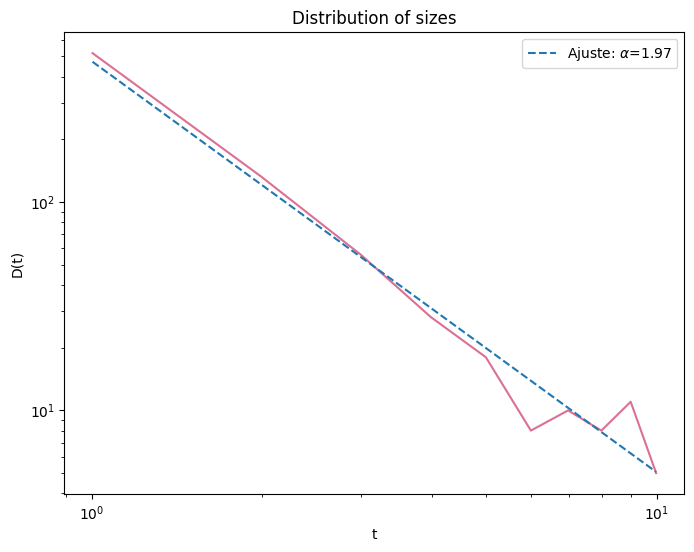

In [654]:
# Ignorar las primeras 1000 muestras (como en tu ejemplo)
data = avalanches_size[:]

# Crear bins en escala logarítmica
bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 1000)

# Construir el histograma con bins logarítmicos
dt, t_edges = np.histogram(data, bins=bins)

# Calcular el punto medio de los bins
t = 0.5 * (t_edges[1:] + t_edges[:-1])
#print(dt)
limit = t < 1e1 
t = t[limit]
dt = dt[limit]
# Filtrar ceros para evitar problemas en log-log
nozero = dt != 0
dt = dt[nozero]
t = t[nozero]

# Regresión lineal en log-log
log_t = np.log(t)
log_dt = np.log(dt)
slope, intercept, r_value, p_value, std_err = linregress(log_t, log_dt)
alpha = -slope  # Exponente de la ley de potencia
C = np.exp(intercept)  # Constante de escala
'''power_fit = powerlaw.Fit(dt, xmin=np.min(dt), xmax=np.max(dt))
alpha = np.round(power_fit.power_law.alpha, 4)-1
print(alpha)'''

# Generar línea ajustada
fit_line = C * t**(-alpha)

# Graficar
plt.figure(figsize=(8, 6))
plt.loglog(t, dt, color = 'palevioletred')
plt.loglog(t, fit_line, linestyle="--", label=f'Ajuste: $ \\alpha $={alpha:.2f}')
plt.xlabel('t')
plt.ylabel('D(t)')
plt.title('Distribution of sizes')
plt.legend()
plt.show()

In [688]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Parameters
N = 300
alphas = [1.2, 1.4, 1.5, 1.7]  # Testing different values of alpha
uu = 0.2
tau_J = 10
tau_ext = 30
tau_d = 1  # delay input
theta = 1
I_ext = 0.025
max_time = 100000
dt = 0.1
treshold = 1

results = {}

for alpha in alphas:
    # Initialize neuron potentials
    hi = np.float16(np.random.uniform(0, treshold, N))
    array_neurons = np.arange(0, N)
    initial_potentials = dict(zip(array_neurons, hi))

    # Create the network
    G = nx.complete_graph(N)
    for u, v, data in G.edges(data=True):
        data['weight'] = np.random.uniform(0.5, alpha / uu)  # Random initial weights
    nx.set_node_attributes(G, initial_potentials, 'potential')

    # Tracking variables
    tau_spikes_track = [[] for _ in range(tau_d + 1)]
    avalanches_size = []
    time_series = []
    current_avalanche = 0

    for t in range(max_time):
        if t % tau_ext == 0:  # Apply external input periodically
            random_node = np.random.randint(N)
            G.nodes[random_node]['potential'] += I_ext
            if current_avalanche > 0:
                avalanches_size.append(current_avalanche)
                current_avalanche = 0

        # Update potentials and track spikes
        current_potentials = nx.get_node_attributes(G, "potential")
        current_potentials = np.array(list(current_potentials.values()))
        spike_neurons = np.argwhere(current_potentials > theta).flatten()
        current_potentials[spike_neurons] -= 1  # Reset spiking neurons

        nx.set_node_attributes(G, dict(zip(array_neurons, current_potentials)), 'potential')
        tau_spikes_track.append(spike_neurons)

        # Update synaptic weights
        for u, v, data in G.edges(data=True):
            data['weight'] += (alpha / uu - data['weight']) * (dt / tau_J)

        # Process delayed spikes
        if t > tau_d:
            tau_spikes_track.pop(0)
            len_spikes = len(tau_spikes_track[0])
            if len_spikes != 0:
                current_avalanche += len_spikes
                time_series.append(current_avalanche)
                for pre_synaptic in tau_spikes_track[0]:
                    post_synaptics = list(G.neighbors(int(pre_synaptic)))
                    for post_synaptic in post_synaptics:
                        weight = G[int(pre_synaptic)][int(post_synaptic)]['weight']
                        G.nodes[int(post_synaptic)]['potential'] += (1 / N) * uu * weight
                        G[int(pre_synaptic)][int(post_synaptic)]['weight'] -= uu

    # Store results for this alpha
    results[alpha] = {
        "avalanches_size": avalanches_size,
        "time_series": time_series,
    }

# Con paralelización

In [ ]:
import numpy as np
import networkx as nx
from concurrent.futures import ProcessPoolExecutor

# Parameters
N = 300
alphas = [1.2, 1.4, 1.5, 1.7]  # Testing different values of alpha
uu = 0.2
tau_J = 10
tau_ext = 30
tau_d = 1  # delay input
theta = 1
I_ext = 0.025
max_time = 100000
dt = 0.1
treshold = 1

def simulate_alpha(alpha):
    # Initialize neuron potentials
    hi = np.float16(np.random.uniform(0, treshold, N))
    array_neurons = np.arange(0, N)
    initial_potentials = dict(zip(array_neurons, hi))

    # Create the network
    G = nx.complete_graph(N)
    for u, v, data in G.edges(data=True):
        data['weight'] = np.random.uniform(0.5, alpha / uu)  # Random initial weights
    nx.set_node_attributes(G, initial_potentials, 'potential')

    # Tracking variables
    tau_spikes_track = [[] for _ in range(tau_d + 1)]
    avalanches_size = []
    time_series = []
    current_avalanche = 0

    for t in range(max_time):
        if t % tau_ext == 0:  # Apply external input periodically
            random_node = np.random.randint(N)
            G.nodes[random_node]['potential'] += I_ext
            if current_avalanche > 0:
                avalanches_size.append(current_avalanche)
                current_avalanche = 0

        # Update potentials and track spikes
        current_potentials = nx.get_node_attributes(G, "potential")
        current_potentials = np.array(list(current_potentials.values()))
        spike_neurons = np.argwhere(current_potentials > theta).flatten()
        current_potentials[spike_neurons] -= 1  # Reset spiking neurons

        nx.set_node_attributes(G, dict(zip(array_neurons, current_potentials)), 'potential')
        tau_spikes_track.append(spike_neurons)

        # Update synaptic weights
        for u, v, data in G.edges(data=True):
            data['weight'] += (alpha / uu - data['weight']) * (dt / tau_J)

        # Process delayed spikes
        if t > tau_d:
            tau_spikes_track.pop(0)
            len_spikes = len(tau_spikes_track[0])
            if len_spikes != 0:
                current_avalanche += len_spikes
                time_series.append(current_avalanche)
                for pre_synaptic in tau_spikes_track[0]:
                    post_synaptics = list(G.neighbors(int(pre_synaptic)))
                    for post_synaptic in post_synaptics:
                        weight = G[int(pre_synaptic)][int(post_synaptic)]['weight']
                        G.nodes[int(post_synaptic)]['potential'] += (1 / N) * uu * weight
                        G[int(pre_synaptic)][int(post_synaptic)]['weight'] -= uu

    # Return results for this alpha
    return alpha, {
        "avalanches_size": avalanches_size,
        "time_series": time_series,
    }

# Parallelize the simulation for each alpha
results = {}
with ProcessPoolExecutor() as executor:
    futures = [executor.submit(simulate_alpha, alpha) for alpha in alphas]
    for future in futures:
        alpha, result = future.result()
        results[alpha] = result

# Visualización de resultados

In [17]:
import pickle

ruta_pickle = "resultados.pkl"
with open(ruta_pickle, "rb") as file:
    results = pickle.load(file)
results

[1.1, 1.2, 1.4, 1.5, 1.7, 1.8]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1.1
0.0027833386031329566
1.2
0.1325072031747166
1.4
0.0
1.5
0.08542853416766981
1.7
0.06609220087607502
1.8
0.0309997570425462


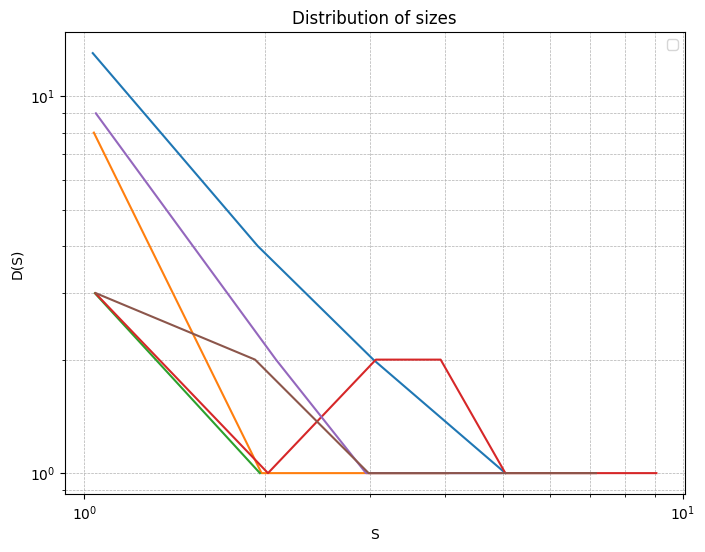

In [23]:
plt.figure(figsize=(8, 6))
for alpha in list(results.keys()):
    print(alpha)
    data = results[alpha]["avalanches_size"]
    # Crear bins en escala logarítmica
    bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 100)
    #bins = np.linspace(min(data), max(data), 100000)
    
    # Construir el histograma con bins logarítmicos
    dt, t_edges = np.histogram(data, bins=bins)
    
    # Calcular el punto medio de los bins
    t = 0.5 * (t_edges[1:] + t_edges[:-1])
    #print(dt)
    limit = t < 1e1
    t = t[limit]
    dt = dt[limit]
    # Filtrar ceros para evitar problemas en log-log
    nozero = dt != 0
    dt = dt[nozero]
    t = t[nozero]
    
    # Regresión lineal en log-log
    log_t = np.log(t)
    log_dt = np.log(dt)
    slope, intercept, r_value, p_value, std_err = linregress(log_t, log_dt)
    print(p_value)
    alpha = -slope  # Exponente de la ley de potencia
    C = np.exp(intercept)  # Constante de escala
    
    # Generar línea ajustada
    fit_line = C * t**(-alpha)
    plt.loglog(t, dt)
    #plt.loglog(t, fit_line, linestyle="--", label=f'Ajuste: $ \\alpha $={alpha:.2f}')
    plt.xlabel('S')
    plt.ylabel('D(S)')
    plt.title('Distribution of sizes')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

1.2
1.4
1.5
1.7


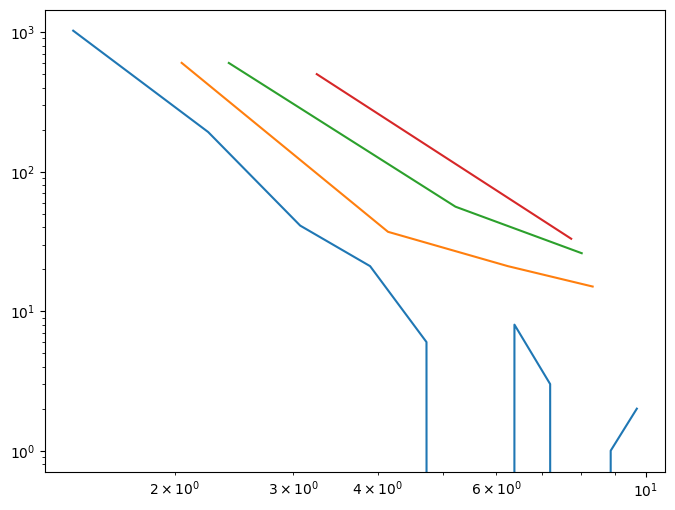

In [755]:
plt.figure(figsize=(8, 6))
for alpha in alphas:
    print(alpha)
    data = results[alpha]["avalanches_size"]
    dt, t_edges = np.histogram(data, bins = 1000)
    t = 0.5 * (t_edges[1:] + t_edges[:-1])
    limit = t < 1e1 
    t = t[limit]
    dt = dt[limit]
    plt.loglog(t, dt)

plt.show()

In [681]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.animation as animation

mpl.rcParams['animation.embed_limit'] = 10000
# Parameters
N = 300
alpha = 1.4
uu = 0.2
tau_J = 10
tau_ext = 30
tau_d = 1  # Delay input
theta = 1
I_ext = 0.25
max_time = 1  # For visualization
dt = 0.01

# Initialize the graph
hi = np.float16(np.random.uniform(0, theta, N))
array_neurons = np.arange(0, N)
initial_potentials = dict(zip(array_neurons, hi))

G = nx.complete_graph(N)
for u, v, data in G.edges(data=True):
    data['weight'] = np.random.uniform(0.5, alpha / uu)

nx.set_node_attributes(G, initial_potentials, 'potential')

# Tracking variables
tau_spikes_track = []
avalanches_size = []
current_avalanche = 0

# Setup animation
fig, ax = plt.subplots(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)
node_colors = ['blue' for _ in range(N)]

def update(frame):
    global tau_spikes_track, current_avalanche, node_colors

    # External stimulus
    if frame % tau_ext == 0:
        random_node = np.random.randint(N)
        G.nodes[random_node]['potential'] += I_ext
        node_colors[random_node] = 'red'  # Highlight external stimulus

    # Check spiking neurons
    current_potentials = nx.get_node_attributes(G, "potential")
    current_potentials = np.array(list(current_potentials.values()))
    spike_neurons = np.argwhere(current_potentials > theta).flatten()
    node_colors = ['blue' if i not in spike_neurons else 'green' for i in range(N)]
    current_potentials[spike_neurons] -= 1
    nx.set_node_attributes(G, dict(zip(array_neurons, current_potentials)), 'potential')

    # Update weights and propagate spikes
    for u, v, data in G.edges(data=True):
        data['weight'] += (alpha / uu - data['weight']) * (dt / tau_J)
    if tau_spikes_track:
        len_spikes = len(tau_spikes_track[0])
        if len_spikes != 0:
            current_avalanche += len_spikes
            for pre_synaptic in tau_spikes_track[0]:
                post_synaptics = list(G.neighbors(int(pre_synaptic)))
                for post_synaptic in post_synaptics:
                    weight = G[int(pre_synaptic)][int(post_synaptic)]['weight']
                    G.nodes[int(post_synaptic)]['potential'] += (1 / N) * uu * weight
                    G[int(pre_synaptic)][int(post_synaptic)]['weight'] = max(0, weight - uu)
        tau_spikes_track.pop(0)
    tau_spikes_track.append(spike_neurons)

    # Visualize
    edge_weights = nx.get_edge_attributes(G, 'weight').values()
    nx.draw(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        edge_color=list(edge_weights),
        edge_cmap=plt.cm.Blues,
        node_size=50,
        with_labels=False,
    )
    ax.set_title(f"Time Step: {frame}")

ani = animation.FuncAnimation(fig, update, frames=max_time, interval=50, repeat=False)
ani.save("levine_video.mp4", writer="ffmpeg", fps=20)


NameError: name 'mpl' is not defined

In [565]:
from concurrent.futures import ThreadPoolExecutor

def update_edge_weights(edges, alpha, uu, dt, tau_J):
    for u, v, data in edges:
        data['weight'] += (alpha / uu - data['weight']) * (dt / tau_J)

def propagate_spike(pre_synaptic, post_synaptics, G, uu, N):
    for post_synaptic in post_synaptics:
        weight = G[pre_synaptic][post_synaptic]['weight']
        G.nodes[post_synaptic]['potential'] += (1 / N) * uu * weight
        G[pre_synaptic][post_synaptic]['weight'] = weight - uu

def main_simulation(G, max_time, tau_ext, I_ext, theta, alpha, uu, dt, tau_J, tau_d, N):
    tau_spikes_track = []
    array_neurons = list(G.nodes)
    with ThreadPoolExecutor(max_workers=6) as executor:
        for t in range(max_time):
            if t % tau_ext == 0:  # Aplicar corriente externa cada tau_input
                random_node = np.random.randint(N)
                G.nodes[random_node]['potential'] += I_ext

            current_potentials = nx.get_node_attributes(G, "potential")
            current_potentials = np.array(list(current_potentials.values()))
            spike_neurons = np.argwhere(current_potentials > theta).flatten()
            current_potentials[spike_neurons] -= 1
            nx.set_node_attributes(G, dict(zip(array_neurons, current_potentials)), 'potential')
            tau_spikes_track.append(spike_neurons)

            # Paralelización de la actualización de pesos
            edges = list(G.edges(data=True))
            future = executor.submit(update_edge_weights, edges, alpha, uu, dt, tau_J)

            if t > tau_d:
                tau_spikes_track.pop(0)
                if len(tau_spikes_track[0]) != 0:
                    print(tau_spikes_track[1].shape[0])
                    for pre_synaptic in tau_spikes_track[0]:
                        post_synaptics = list(G.neighbors(int(pre_synaptic)))
                        executor.submit(propagate_spike, pre_synaptic, post_synaptics, G, uu, N)

    print("Simulación completada")
main_simulation(G, max_time, tau_ext, I_ext, theta, alpha, uu, dt, tau_J, tau_d, N)

0
0
0
0
3
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


KeyboardInterrupt: 

In [350]:
for node in G.nodes:
    inputs = sum(G[neighbor][node]['weight'] for neighbor in G.neighbors(node))
    G.nodes[node]['potential'] += I_ext * dt + (inputs / N) * dt

In [400]:
current_potentials = nx.get_node_attributes(G, "potential")
current_potentials = np.array(list(current_potentials.values()))

index = np.argwhere(current_potentials > theta).flatten()

inde

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97])